In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/employee_messy.csv')
df.head(50)

,employee_id,department,salary,years_experience,performance_score,promotion_last_5years,work_hours_per_week
0,EMP5188,Tech,$143624,29,NaN,0,55
1,EMP6011,Finance,85838.85,29,5,1,29
2,EMP7441,Finance,115k,26,1,0,35
3,EMP3957,hr,80k,23,1,No,53
4,EMP9981,HR,NaN,17,4,1,37
5,EMP3287,technology,145882.38,18,4,1,21
6,EMP2289,technology,128954.62,NaN,5,1,39
7,EMP3478,IT,85808.80,NaN,2,NaN,60
8,EMP7882,IT,43835.16,21,excellent,0,52
9,EMP9958,NaN,132681.16,30,3,1,58


In [15]:
df.isnull().mean()*100

,0
employee_id,2.132
department,9.772
salary,6.912
years_experience,7.876
performance_score,9.712
promotion_last_5years,9.808
work_hours_per_week,6.988


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   employee_id            24467 non-null  object
 1   department             22557 non-null  object
 2   salary                 23272 non-null  object
 3   years_experience       23031 non-null  object
 4   performance_score      22572 non-null  object
 5   promotion_last_5years  22548 non-null  object
 6   work_hours_per_week    23253 non-null  object
dtypes: object(7)
memory usage: 1.3+ MB


In [17]:
# Check for missing values
print("\n🔍 Missing values summary:")
print(df.isnull().sum())


🔍 Missing values summary:
employee_id               533
department               2443
salary                   1728
years_experience         1969
performance_score        2428
promotion_last_5years    2452
work_hours_per_week      1747
dtype: int64


In [18]:
df.columns = df.columns.str.capitalize()

In [19]:
df['Department'] = df['Department'].str.capitalize()
#حولنا اول حرف من كل كلمه الي كابيتال للتنسيق


In [20]:
df['Department'] = df['Department'].replace('Tech' , 'Technology')
df['Department'] = df['Department'].replace('Human resources' , 'Hr')


In [21]:
df.head(50
        )

,Employee_id,Department,Salary,Years_experience,Performance_score,Promotion_last_5years,Work_hours_per_week
0,EMP5188,Technology,$143624,29,NaN,0,55
1,EMP6011,Finance,85838.85,29,5,1,29
2,EMP7441,Finance,115k,26,1,0,35
3,EMP3957,Hr,80k,23,1,No,53
4,EMP9981,Hr,NaN,17,4,1,37
5,EMP3287,Technology,145882.38,18,4,1,21
6,EMP2289,Technology,128954.62,NaN,5,1,39
7,EMP3478,It,85808.80,NaN,2,NaN,60
8,EMP7882,It,43835.16,21,excellent,0,52
9,EMP9958,NaN,132681.16,30,3,1,58


In [22]:
df['Department']= df['Department'].fillna('Unknown')
df['Employee_id']= df['Employee_id'].fillna('Unknown')
#مليت القيم الفارغه بستخدام fillna

In [23]:
df['Salary'] = df['Salary'].fillna('0')
df['Salary'] = df['Salary'].str.replace('$', '')
df['Salary'] = df['Salary'].str.replace('k', '')
df['Salary'] = df['Salary'].str.replace(',', '.')

In [24]:
df['Salary'] = df['Salary'].astype(float)
#غيرت الداتا تايب عشان اعرف اشتغل علي العمود

In [25]:
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df= df[(df["Salary"] >= lower) & (df["Salary"] <= upper)]

boxplot


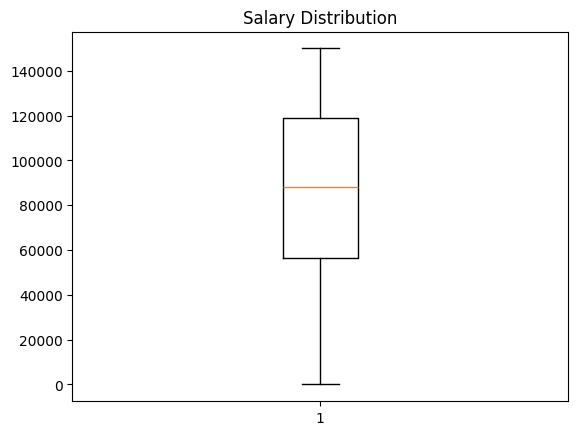

In [26]:
print('boxplot')
plt.boxplot(df["Salary"])
plt.title("Salary Distribution")
plt.show()

In [27]:
df1= df['Salary'].median()
print(df1)

87957.69


In [28]:
df['Salary'] = df['Salary'].replace(0.00 , 87957.69 )
#عوضنا بي المتوسط

In [29]:
df['Years_experience'] = df['Years_experience'].fillna('0')
df['Years_experience'] = df['Years_experience'].str.replace('-' , "")
df['Years_experience'] = df['Years_experience'].str.replace('five' ,'5')
#غيرت نوع الداتا تايب عشان اعر ف اشتغل عليها
df['Years_experience'] = df['Years_experience'].astype(int)

boxplot


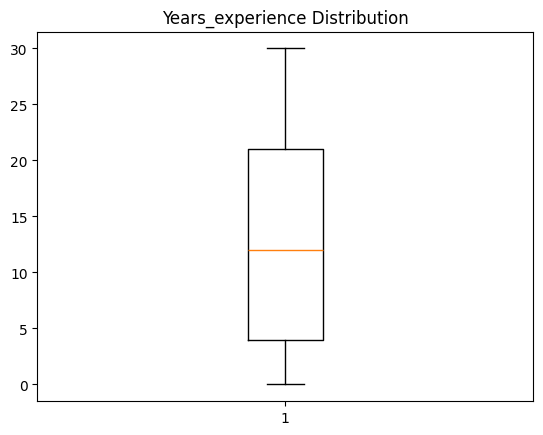

In [30]:
#اتاكدت ان مفيش اي اوتلاير
Q1 = df["Years_experience"].quantile(0.25)
Q3 = df["Years_experience"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df= df[(df["Years_experience"] >= lower) & (df["Years_experience"] <= upper)]
#عملت بوكس بلوت عشان اشوف في اوتلاير ولا لا
print('boxplot')
plt.boxplot(df["Years_experience"])
plt.title("Years_experience Distribution")
plt.show()


In [31]:
#جبت متوسط عدد سنين الخبره
df_mean= df['Years_experience'].mean()
print(df_mean)
#عوضت بي المتوسط اللي جبته
df['Years_experience']=df['Years_experience'].replace( 0 , 14)

12.735217186227006


In [32]:
df['Performance_score'] = df['Performance_score'].fillna('0')
df['Performance_score'] = df['Performance_score'].replace('excellent' ,'0')
df['Performance_score'] = df['Performance_score'].astype(int)
df_mean= df['Performance_score'].mean()
print(df_mean)
#df['Performance_score']=df['Performance_score'].replace( 0 , 2)
df['Performance_score']=df['Performance_score'].replace( 0 , 2)

2.414390463530723


In [33]:
df['Promotion_last_5years'] = df['Promotion_last_5years'].fillna("Unknow")
df['Promotion_last_5years'] = df['Promotion_last_5years'].str.replace('0','No')
df['Promotion_last_5years'] = df['Promotion_last_5years'].str.replace('1' ,'Yes')
df['Promotion_last_5years'] = df['Promotion_last_5years'].str.capitalize()

In [34]:
#اول حاجه هعوض مكان القيم الفارغه بي 0 عشان
df['Work_hours_per_week'] = df['Work_hours_per_week'].fillna('0')
df['Work_hours_per_week'] = df['Work_hours_per_week'].str.replace('hrs' ,'')
df['Work_hours_per_week'] = df['Work_hours_per_week'].astype(int)
df_mean1= df['Work_hours_per_week'].mean()
df['Work_hours_per_week']=df['Work_hours_per_week'].replace( 0 , 41)

In [35]:
import seaborn as sns

Correlation Matrix: 



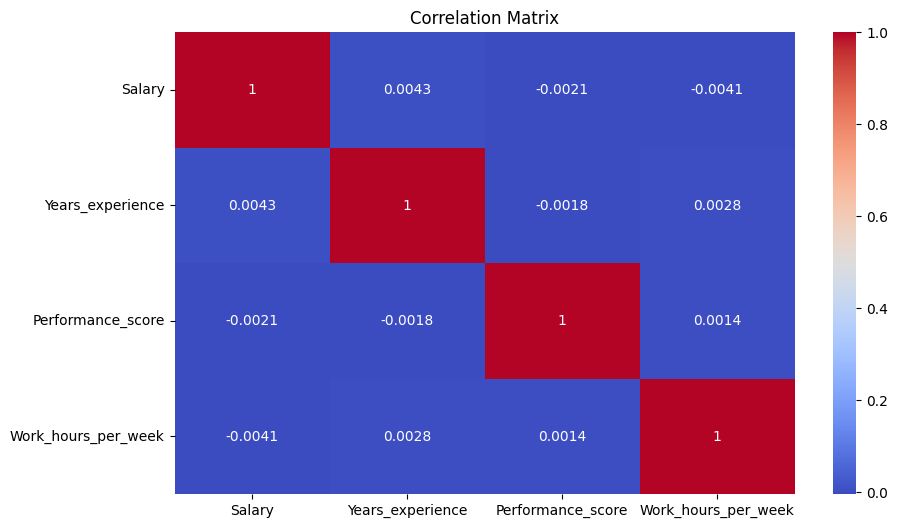

In [36]:
print("Correlation Matrix: \n")
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [37]:
pl5 = df['Promotion_last_5years'].value_counts()
print(pl5)

Promotion_last_5years
Yes       10654
No        10375
Unknow     2292
Name: count, dtype: int64


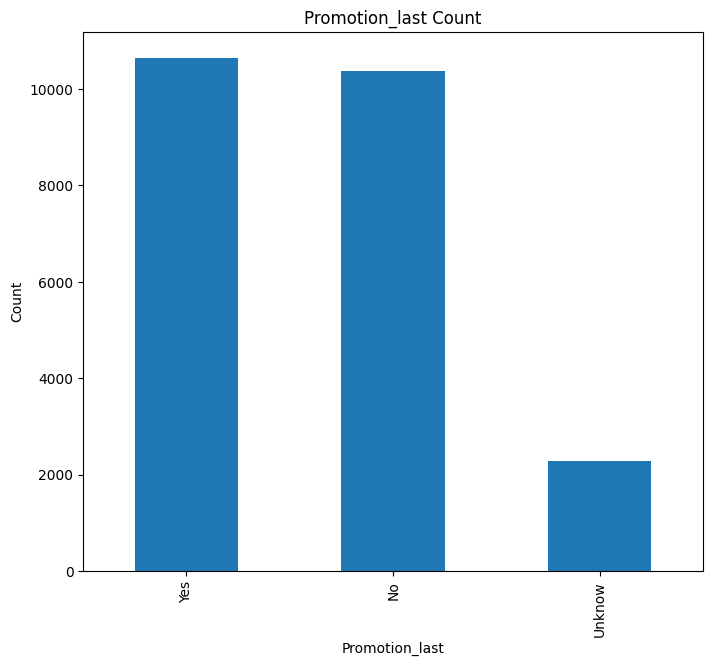

In [38]:
plt.figure(figsize=(8, 7))
pl5.plot(kind="bar")
plt.xlabel("Promotion_last")
plt.ylabel("Count")
plt.title("Promotion_last Count")
plt.show()

In [39]:

df.head(50)

,Employee_id,Department,Salary,Years_experience,Performance_score,Promotion_last_5years,Work_hours_per_week
0,EMP5188,Technology,143624.00,29,2,No,55
1,EMP6011,Finance,85838.85,29,5,Yes,29
2,EMP7441,Finance,115.00,26,1,No,35
3,EMP3957,Hr,80.00,23,1,No,53
4,EMP9981,Hr,87957.69,17,4,Yes,37
5,EMP3287,Technology,145882.38,18,4,Yes,21
6,EMP2289,Technology,128954.62,14,5,Yes,39
7,EMP3478,It,85808.80,14,2,Unknow,60
8,EMP7882,It,43835.16,21,2,No,52
9,EMP9958,Unknown,132681.16,30,3,Yes,58


In [40]:
df.isnull().sum()

,0
Employee_id,0
Department,0
Salary,0
Years_experience,0
Performance_score,0
Promotion_last_5years,0
Work_hours_per_week,0


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23321 entries, 0 to 24999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Employee_id            23321 non-null  object 
 1   Department             23321 non-null  object 
 2   Salary                 23321 non-null  float64
 3   Years_experience       23321 non-null  int64  
 4   Performance_score      23321 non-null  int64  
 5   Promotion_last_5years  23321 non-null  object 
 6   Work_hours_per_week    23321 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 1.4+ MB


In [42]:
df.to_csv("clean_data.csv", index=False)
from google.colab import files

df.to_csv("clean_data.csv", index=False)

files.download("clean_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>